# HSE 2025: Mathematical Methods for Data Analysis

## Homework 4

**Warning 1**: You have 10 days for this assignemnt.  **it is better to start early (!)**

**Warning 2**: it is critical to describe and explain what you are doing and why, use markdown cells


### Contents

#### Decision Trees - 4 points
* [Task 1](#task1) (0.25 points)
* [Task 2](#task2) (0.25 points)
* [Task 3](#task3) (1 points)
* [Task 4](#task4) (0.5 points)
* [Task 5](#task5) (0.5 points)
* [Task 6](#task6) (1 points)
* [Task 7](#task7) (0.5 points)
* [Task 8](#task8) (0.5 points)

#### Ensembles - 4 points
* [Task 1](#task2_1) (0.25 point)
* [Task 2](#task2_2) (1.5 points)
* [Task 3](#task2_3) (0.25 points)
* [Task 4](#task2_4) (0.5 points)
* [Task 5](#task2_4) (0.5 points)

#### Ensembles - 2 points
* [Task 1](#task2_1) (0.4 point)
* [Task 2](#task2_2) (0.5 points)
* [Task 3](#task2_3) (0.5 points)
* [Task 4](#task2_4) (0.5 points)
* [Task 5](#task2_4) (0.1 points)

In [1]:
1

1

In [3]:
%pip install pandas numpy matplotlib scikit-learn

  Using cached matplotlib-3.10.7-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.0.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached scipy-1.16.3-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolc

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = (11, 5)
%matplotlib inline

# Part 1. Decision Tree Regressor

In this task you will be implementing decision tree for the regression by hand.

### Task 1 <a id="task1"></a> (0.25 points)

Here you should implement the function `H()` which calculates impurity criterion. We will be training regression tree, and will take mean absolute deviation as impurity criterion.

* You cannot use loops
* If `y` is empty, the function should return 0

In [5]:
def H(y):
    """
    Calculate impurity criterion

    Parameters
    ----------
    y : np.array
        array of objects target values in the node

    Returns
    -------
    H(R) : float
        Impurity in the node (measuread by variance)
    """
    y = np.asarray(y)
    if y.size == 0:
        return 0.0
    return np.var(y, ddof=0)


In [6]:
# Test the function
assert np.allclose(H(np.array([4, 2, 2, 2])), 0.75)
assert np.allclose(H(np.array([])), 0.0)

### Task 2 <a id="task2"></a>  (0.25 points)

To find the best split in the node we need to calculate the cost function. Denote:
- `R` all the object in the node
- `j` index of the feature selected for the split
- `t` threshold
- `R_l` and `R_r` objects in the left and right child nodes correspondingly

We get the following cost function:

$$
Q(R, j, t) =\frac{|R_\ell|}{|R|}H(R_\ell) + \frac{|R_r|}{|R|}H(R_r) \to \min_{j, t},
$$

Implement the function `Q`, which should calculate value of the cost function for a given feature and threshold.

In [7]:
def Q(X, y, j, t):
    """
    Calculate cost function
    Parameters
    ----------
    X : ndarray
        array of objects in the node
    y : ndarray
        array of target values in the node
    j : int
        feature index (column in X)
    t : float
        threshold

    Returns
    -------
    Q : float
        Value of the cost function
    """
    y = np.asarray(y)
    if y.size == 0:
        return 0.0
    y_left = y[X[:, j] <= t]
    y_right = y[X[:, j] > t]
    return (y_left.size * H(y_left) + y_right.size * H(y_right)) / y.size

### Task 3 <a id="task3"></a>  (1 points)

Now, let's implement `MyDecisionTreeRegressor` class. More specifically, you need to implement the following methods:

- `best_split`
- `grow_tree`
- `get_prediction`

Also, please add `min_samples_leaf` parameter to your class

Read docstrings for more details. Do not forget to use function `Q` implemented above, when finding the `best_split`

In [8]:
class Node(object):
    """
    Class for a decision tree node.

    Parameters
    ----------
    right : Node() or None
        Right child
    left : Node() or None
        Left child
    threshold: float

    column: int

    depth: int

    prediction: float
        prediction of the target value in the node
        (average values calculated on a train dataset)
    is_terminal:bool
        indicates whether it is a terminal node (leaf) or not
    """
    def __init__(self):
        self.right = None
        self.left = None
        self.threshold = None
        self.column = None
        self.depth = None
        self.is_terminal = False
        self.prediction = None

    def __repr__(self):
        if self.is_terminal:
            node_desc = 'Pred: {:.2f}'.format(self.prediction)
        else:
            node_desc = 'Col {}, t {:.2f}, Pred: {:.2f}'. \
            format(self.column, self.threshold, self.prediction)
        return node_desc

In [9]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted, validate_data

class MyDecisionTreeRegressor(RegressorMixin, BaseEstimator):
    """
    Class for a Decision Tree Regressor.

    Parameters
    ----------
    max_depth : int
        Max depth of a decision tree.
    min_samples_split : int
        Minimal number of samples (objects) in a node to make a split.
    min_samples_leaf: int
        Minimum number of samples (objects) in left and right branches after splitting the current node
    """
    def __init__(self, max_depth=3, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

    def best_split(self, X: np.ndarray, y: np.ndarray):
        """
        Find the best split in terms of Q of data in a given decision tree node.
        Try all features and thresholds.

        Parameters
        ----------
        X : ndarray, shape (n_objects, n_features)
            Objects in the parent node
        y : ndarray, shape (n_objects, )
            1D array with the object labels.

        Returns
        -------
        best_split_column : int
            Index of the best split column
        best_threshold : float
            The best split condition.
        X_left : ndarray, shape (n_objects_l, n_features)
            Objects in the left child
        y_left : ndarray, shape (n_objects_l, )
            Objects labels in the left child.
        X_right : ndarray, shape (n_objects_r, n_features)
            Objects in the right child
        y_right : ndarray, shape (n_objects_r, )
            Objects labels in the right child.
        """
        n_features = X.shape[1]

        best_cost = H(y)
        best_split_column = None
        best_threshold = None
        X_left = X_right = None
        y_left = y_right = None

        for j in range(n_features):
            xj = X[:, j]
            thresholds = np.unique(xj)

            for t in thresholds:
                mask_left = xj <= t
                mask_right = ~mask_left
                n_left = np.sum(mask_left)
                n_right = np.sum(mask_right)

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                cost = Q(X, y, j, t)
                if cost < best_cost:
                    best_cost = cost
                    best_split_column = j
                    best_threshold = t
                    X_left = X[mask_left]
                    y_left = y[mask_left]
                    X_right = X[mask_right]
                    y_right = y[mask_right]

        return best_split_column, best_threshold, X_left, y_left, X_right, y_right

    def is_terminal(self, node: Node, y: np.ndarray):
        """
        Check terminality conditions based on `max_depth`,
        `min_samples_split` parameters for a given node.

        Parameters
        ----------
        node : Node,

        y : ndarray, shape (n_objects, )
            Object labels.

        Returns
        -------
        Is_termial : bool
            If True, node is terminal
        """
        if node.depth >= self.max_depth:
            return True
        if len(y) < self.min_samples_split:
            return True
        return False

    def grow_tree(self, node: Node, X: np.ndarray, y: np.ndarray):
        """
        Reccurently grow the tree from the `node` using a `X` and `y` as a dataset:
         - check terminality conditions
         - find best split if node is not terminal
         - add child nodes to the node
         - call the function recursively for the added child nodes

        Parameters
        ----------
        node : Node() object
            Current node of the decision tree.
        X : ndarray, shape (n_objects, n_features)
            Objects
        y : ndarray, shape (n_objects)
            Labels
        """
        node.prediction = float(np.mean(y))

        if self.is_terminal(node, y):
            node.is_terminal = True
            return

        (best_split_column,
         best_threshold,
         X_left, y_left,
         X_right, y_right) = self.best_split(X, y)

        if best_split_column is None:
            node.is_terminal = True
            return

        node.column = best_split_column
        node.threshold = float(best_threshold)
        node.is_terminal = False

        left_node = Node()
        right_node = Node()

        left_node.depth = node.depth + 1
        right_node.depth = node.depth + 1

        left_node.prediction = float(np.mean(y_left))
        right_node.prediction = float(np.mean(y_right))

        node.left = left_node
        node.right = right_node

        self.grow_tree(left_node, X_left, y_left)
        self.grow_tree(right_node, X_right, y_right)


    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Fit the Decision Tree Regressor.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            The input samples.
        y : ndarray, shape (n_samples,) or (n_samples, n_outputs)
            The target values.
        Returns
        -------
        self : object
            Returns self.
        """
        X, y = validate_data(self, X, y, accept_sparse=False)
        self.is_fitted_ = True

        self.tree_ = Node()
        self.tree_.depth = 1
        self.tree_.prediction = float(np.mean(y))

        self.grow_tree(self.tree_, X, y)
        return self

    def get_prediction(self, node: Node, x: np.ndarray):
        """
        Get prediction for an object `x`
            - Return prediction of the `node` if it is terminal
            - Otherwise, recursively call the function to get
            predictions of the proper child

        Parameters
        ----------
        node : Node() object
            Current node of the decision tree.
        x : ndarray, shape (n_features,)
            Array of feature values of one object.
        Returns
        -------
        y_pred : float
            Prediction for an object x
        """
        if node.is_terminal or node.column is None:
            return node.prediction

        if x[node.column] <= node.threshold:
            return self.get_prediction(node.left, x)
        else:
            return self.get_prediction(node.right, x)

    def predict(self, X: np.ndarray):
        """
        Get prediction for each object in X

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            The input samples.
        Returns
        -------
        y : ndarray, shape (n_samples,)
            Returns predictions.
        """
        check_is_fitted(self, 'is_fitted_')
        X = validate_data(self, X, accept_sparse=False, reset=False)

        y_predicted = []
        for x in X:
            y_curr = self.get_prediction(self.tree_, x)
            y_predicted.append(y_curr)
        return np.array(y_predicted)

In [10]:
# check yourself
from sklearn.utils.estimator_checks import check_estimator

check_estimator(MyDecisionTreeRegressor())

[{'estimator': MyDecisionTreeRegressor(),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': MyDecisionTreeRegressor(),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': MyDecisionTreeRegressor(),
  'check_name': 'check_estimator_tags_renamed',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': MyDecisionTreeRegressor(),
  'check_name': 'check_valid_tag_types',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': MyDecisionTreeRegressor(),
  'check_name': 'check_estimator_repr',
  'exception': None,
  'status'

### Task 4 <a id="task4"></a>  (0.5 points)

Load california housing dataset and split it on the train ($75\%$) and test ($25\%$). Fit Decision Tree of **depth 1 and 2** (root node has **depth 0**) and make the following plot for every case :

- Scatter plot of the traning points for each splitted feature (selected for split feature on the x-axis, target variable on the y-axis). Show the resulting thresholds

After that, fit analogical model from sklearn and visual it

Compare `MAE` on train and test. Have trees overfitted?

In [11]:
from sklearn.datasets import fetch_california_housing
cal = fetch_california_housing(as_frame=True)
df: pd.DataFrame = cal.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
y: pd.Series = df['MedHouseVal']
X: pd.DataFrame = df.drop('MedHouseVal', axis=1)


=== MyDecisionTreeRegressor, max_depth=1 ===
MAE train (my): 0.9127
MAE test  (my): 0.9100
MAE train (sklearn): 0.7416
MAE test  (sklearn): 0.7524


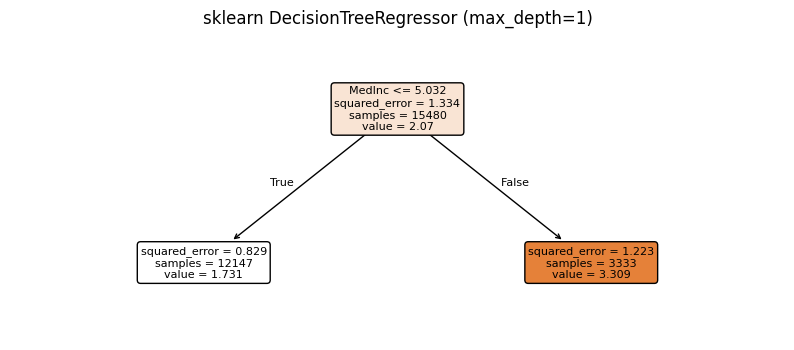


=== MyDecisionTreeRegressor, max_depth=2 ===


KeyboardInterrupt: 

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor, plot_tree

X_train: pd.DataFrame
X_test: pd.DataFrame
y_train: pd.Series
y_test: pd.Series
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

def collect_splits(node: Node, splits: dict[int, list[float]]):
    if node is None or node.is_terminal or node.column is None:
        return
    splits.setdefault(node.column, []).append(node.threshold)
    collect_splits(node.left, splits)
    collect_splits(node.right, splits)

results = []

for depth in [1, 2]:
    print(f"\n=== MyDecisionTreeRegressor, max_depth={depth} ===")

    my_tree = MyDecisionTreeRegressor(
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
    )
    my_tree.fit(X_train, y_train)

    y_train_pred_my = my_tree.predict(X_train)
    y_test_pred_my = my_tree.predict(X_test)

    mae_train_my = mean_absolute_error(y_train, y_train_pred_my)
    mae_test_my = mean_absolute_error(y_test, y_test_pred_my)

    print(f"MAE train (my): {mae_train_my:.4f}")
    print(f"MAE test  (my): {mae_test_my:.4f}")

    sk_tree = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42,
    )
    sk_tree.fit(X_train, y_train)

    y_train_pred_sk = sk_tree.predict(X_train)
    y_test_pred_sk = sk_tree.predict(X_test)

    mae_train_sk = mean_absolute_error(y_train, y_train_pred_sk)
    mae_test_sk = mean_absolute_error(y_test, y_test_pred_sk)

    print(f"MAE train (sklearn): {mae_train_sk:.4f}")
    print(f"MAE test  (sklearn): {mae_test_sk:.4f}")

    results.append(
        {
            "max_depth": depth,
            "MAE_train_my": mae_train_my,
            "MAE_test_my": mae_test_my,
            "MAE_train_sklearn": mae_train_sk,
            "MAE_test_sklearn": mae_test_sk,
        }
    )

    splits = {}
    collect_splits(my_tree.tree_, splits)

    for j, ths in splits.items():
        plt.figure()
        plt.scatter(X_train.iloc[:, j], y_train, alpha=0.3, s=10)
        for th in set(ths):
            plt.axvline(th, linestyle="--")
        plt.xlabel(X_train.columns[j])
        plt.ylabel("MedHouseVal")
        plt.title(f"MyTree depth={depth}, feature={X_train.columns[j]}")
        plt.show()

    plt.figure(figsize=(10, 4))
    plot_tree(
        sk_tree,
        feature_names=X_train.columns,
        filled=True,
        rounded=True,
        fontsize=8,
    )
    plt.title(f"sklearn DecisionTreeRegressor (max_depth={depth})")
    plt.show()

pd.DataFrame(results)

### Task 5 <a id="task5"></a> (0.5 points)

Keep working with the Boston dataset.

- Use [Optuna](https://github.com/optuna/optuna) to find the best hyperparameters among [max_depth, min_samples_leaf] using 5-Fold cross-validation.

- Train the model with the best set of hyperparameters on the whole training dataset.

- Report the MAE on the test dataset and the hyperparameters of the best estimator.

[Optuna](https://github.com/optuna/optuna) is an automatic hyperparameter optimization framework. It searches for the best parameters using efficient algorithms (e.g., Tree-structured Parzen Estimator — TPE). It is model-agnostic and works with any Python ML framework. Use TPE algorithms for all tasks.

In [ ]:
import optuna
from sklearn.model_selection import KFold, cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 50)

    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
    )
    return -scores.mean()

/Users/griga/griga/Study/HSE/3-course/ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best params:", study.best_params)
print("Best CV MAE:", study.best_value)

best_model = DecisionTreeRegressor(
    **study.best_params,
    random_state=42,
)
best_model.fit(X_train, y_train)

y_test_pred_best = best_model.predict(X_test)
mae_test_best = mean_absolute_error(y_test, y_test_pred_best)
print("Test MAE (best model):", mae_test_best)

[I 2025-12-07 20:45:43,938] A new study created in memory with name: no-name-ec504869-e789-407b-8201-1a962b0d9de7
[I 2025-12-07 20:45:44,161] Trial 0 finished with value: 0.4384323557291112 and parameters: {'max_depth': 20, 'min_samples_leaf': 36}. Best is trial 0 with value: 0.4384323557291112.
[I 2025-12-07 20:45:44,270] Trial 1 finished with value: 0.5552656058193572 and parameters: {'max_depth': 4, 'min_samples_leaf': 38}. Best is trial 0 with value: 0.4384323557291112.
[I 2025-12-07 20:45:44,498] Trial 2 finished with value: 0.4316997575524416 and parameters: {'max_depth': 10, 'min_samples_leaf': 14}. Best is trial 2 with value: 0.4316997575524416.
[I 2025-12-07 20:45:44,749] Trial 3 finished with value: 0.4243388166115175 and parameters: {'max_depth': 18, 'min_samples_leaf': 15}. Best is trial 3 with value: 0.4243388166115175.
[I 2025-12-07 20:45:44,922] Trial 4 finished with value: 0.47946429270999447 and parameters: {'max_depth': 7, 'min_samples_leaf': 39}. Best is trial 3 with

Best params: {'max_depth': 18, 'min_samples_leaf': 15}
Best CV MAE: 0.4243388166115175
Test MAE (best model): 0.41244985851204896


### Task 6 <a id="task6"></a>  (1 points)

Recall definition of bias and variance:
$$
\text{Bias}^2 = \mathbb{E}_{p(x, y)} \left[  (f(x) - \mathbb{E}_{\mathbb{X}}a_{\mathbb{X}}(x))^2 \right] \\
\text{Variance} = \mathbb{E}_{p(x, y)} \left[  \mathbb{V}_{\mathbb{X}}( a_{\mathbb{X}}(x))  \right]
$$

We wil now use the following algorithm to estimate bias and variance:

1. Use bootsrap to create `n_iter` samples from the original dataset: $X_1, \dots, X_{n_iter}$
2. For each bootstrapped sample define out-of-bag (OOB) sample $Z_1, \dots, Z_{n_iter}$, which contain all the observations, which did not appear in the corresponding boostraped sample
3. Fit the model on $X_i$s and compute predictions on $Z_i$s
4. For a given *object* $n$:
     - bias^2: squared difference between true value $y_n$ and average prediction (average over the algorithms, for which $n$ was in OOB)
     - variance: variance of the prediction (predictions of the algorithms, for which $n$ was in OOB)
5. Average bias^2 and variance over all the points
    
**Implement `get_bias_variance` function, using the algorithm above**

*Note:*  You can only use 1 loop (for bootsrap iterations). All other operations should be vectorized.

In [ ]:
from sklearn.base import clone

def get_bias_variance(estimator, x, y, n_iter):
    """
    Calculate bias and variance of the `estimator` using bootstrap OOB.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n_samples = x.shape[0]

    preds = np.full((n_iter, n_samples), np.nan, dtype=float)

    indices = np.arange(n_samples)

    for i in range(n_iter):
        bootstrap_idx = np.random.choice(indices, size=n_samples, replace=True)
        oob_mask = ~np.isin(indices, bootstrap_idx)
        oob_idx = indices[oob_mask]
        if oob_idx.size == 0:
            continue

        model = clone(estimator)
        model.fit(x[bootstrap_idx], y[bootstrap_idx])
        preds[i, oob_idx] = model.predict(x[oob_idx])

    mean_preds = np.nanmean(preds, axis=0)
    var_preds = np.nanvar(preds, axis=0)

    valid_mask = ~np.isnan(mean_preds)
    bias2 = np.mean((y[valid_mask] - mean_preds[valid_mask]) ** 2)
    variance = np.mean(var_preds[valid_mask])

    return bias2, variance

In [ ]:
estimator = MyDecisionTreeRegressor(max_depth=8, min_samples_split=15)
get_bias_variance(estimator, X_train.values, y_train.values, 10)

/var/folders/nx/x_srfg0156df5f9dv23kjfdm0000gn/T/ipykernel_18875/892119378.py:26: RuntimeWarning: Mean of empty slice
  mean_preds = np.nanmean(preds, axis=0)
/var/folders/nx/x_srfg0156df5f9dv23kjfdm0000gn/T/ipykernel_18875/892119378.py:27: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_preds = np.nanvar(preds, axis=0)


(np.float64(0.3914819609165532), np.float64(0.06439778605440416))

### Task 7 <a id="task7"></a>  (0.5 points)

Compute bias and variance for the trees with different min_samples_split. Plot how bias and variance change as min_samples_split increases.

Comment on what you observe, how does your result correspond to theory?

min_samples_split=2: bias^2=0.3690, variance=0.0906
min_samples_split=5: bias^2=0.3708, variance=0.0905
min_samples_split=10: bias^2=0.3699, variance=0.0911
min_samples_split=20: bias^2=0.3722, variance=0.0903
min_samples_split=50: bias^2=0.3684, variance=0.0870
min_samples_split=100: bias^2=0.3733, variance=0.0833


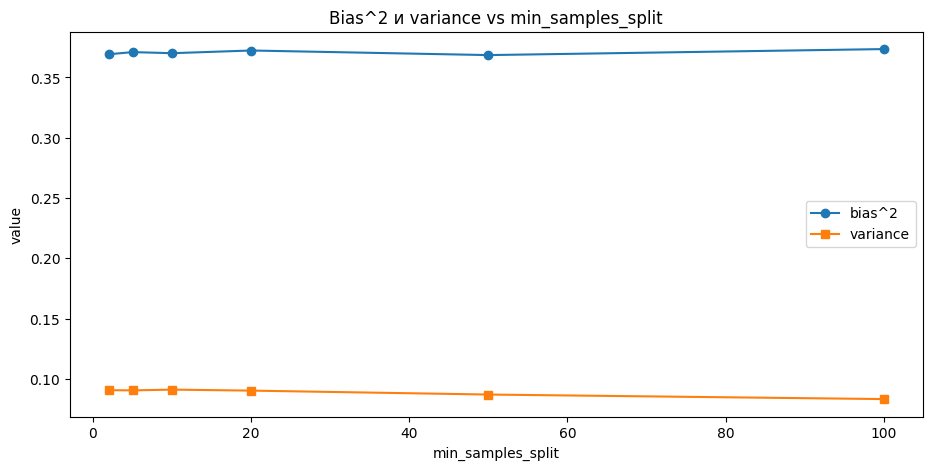

In [ ]:
min_samples_split_values = [2, 5, 10, 20, 50, 100]
bias2_list = []
var_list = []

for mss in min_samples_split_values:
    est = MyDecisionTreeRegressor(
        max_depth=8,
        min_samples_split=mss,
    )
    bias2, var = get_bias_variance(est, X_train.values, y_train.values, n_iter=30)
    bias2_list.append(bias2)
    var_list.append(var)
    print(f"min_samples_split={mss}: bias^2={bias2:.4f}, variance={var:.4f}")

plt.figure()
plt.plot(min_samples_split_values, bias2_list, marker="o", label="bias^2")
plt.plot(min_samples_split_values, var_list, marker="s", label="variance")
plt.xlabel("min_samples_split")
plt.ylabel("value")
plt.legend()
plt.title("Bias^2 и variance vs min_samples_split")
plt.show()

``` your comments here```

### Task 8 <a id="task8"></a>  (0.5 points)

Let's try to reduce variance with bagging. Use `sklearn.ensemble.BaggingRegressor` to get an ensemble and compute its bias and variance.

Answer the following questions:
 - How bagging should affect bias and variance in theory?
 - How bias and variance change (if they change) compared to an individual tree in you experiments?
 - Do your results align with the theory? Why?

In [ ]:
from sklearn.ensemble import BaggingRegressor

base_tree = MyDecisionTreeRegressor(
    max_depth=8,
    min_samples_split=15,
)

bias2_single, var_single = get_bias_variance(
    base_tree,
    X_train.values,
    y_train.values,
    n_iter=30,
)
print(f"Single tree: bias^2={bias2_single:.4f}, variance={var_single:.4f}")

Single tree: bias^2=0.3613, variance=0.0897


In [ ]:
bagging = BaggingRegressor(
    estimator=MyDecisionTreeRegressor(
        max_depth=8,
        min_samples_split=15,
    ),
    n_estimators=25,
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)

bias2_bag, var_bag = get_bias_variance(
    bagging,
    X_train.values,
    y_train.values,
    n_iter=15,
)
print(f"Bagging:    bias^2={bias2_bag:.4f}, variance={var_bag:.4f}")

```your comments here```

# Part 2. Gradient Boosting

In this assignment, you will implement a Gradient Boosting model for binary classification.

The base learners in your model must be the decision trees you have implemented earlier (**MyDecisionTreeRegressor** and **Node**).

The loss function used for boosting will be the logistic (log-loss) loss, as used in logistic regression.


We assume binary labels: $y \in {0, 1}$

The model builds an additive ensemble:
$ F(x) = F_0 + \sum_{m=1}^{M} \eta \cdot h_m(x) $

where:

•	$F(x)$ are raw scores (logits),

•	$F_0$ is the initial prediction computed from the training data,

•	$\eta$ is the learning rate,

•	$h_m(x)$ are predictions of the (m)-th regression tree.


The predicted probability for class 1 must be computed using the sigmoid transformation: $p(x) = \sigma(F(x)) = \frac{1}{1 + e^{-F(x)}}$


### Task 1 <a id="task2_1"></a>  (0.25 points)

In this task, you must derive the expression for the residuals used in Gradient Boosting with logistic loss, which is employed in binary classification.

$L(y, F(x)) = - \Big( y \cdot \log(p(x)) + (1 - y) \cdot \log(1 - p(x)) \Big)$

Сначала считаем производную по \(p\):

$
\frac{\partial L}{\partial p}
= -\left( \frac{y}{p} - \frac{1-y}{1-p} \right)
= -\frac{y(1-p) - (1-y)p}{p(1-p)}
= -\frac{y - yp - p + yp}{p(1-p)}
= -\frac{y - p}{p(1-p)}.
$

Далее $\dfrac{\partial p}{\partial F} = p(1-p)$, так как $p = \sigma(F)$.

Тогда производная по сырому счёту \(F\):

$
\frac{\partial L}{\partial F}
= \frac{\partial L}{\partial p} \cdot \frac{\partial p}{\partial F}
= -\frac{y - p}{p(1-p)} \cdot p(1-p)
= p - y.
$

В градиентном бустинге псевдо-остатки — это минус градиент по \(F\):

$
r(x) = -\frac{\partial L}{\partial F(x)} = y - p(x).
$

**Итого:** на каждом шаге бустинга при логистической потере residuals берутся как

$
r_i = y_i - p(x_i), \quad p(x_i) = \sigma(F(x_i)).
$

### Task 2 <a id="task2_2"></a>  (1.5 points)

Implement class for Gradient Boosting model for binary classification.

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.special import expit

class MyGradientBoostingBinaryClassifier(BaseEstimator, ClassifierMixin):
    """
    Gradient boosting for binary classification (y in {0, 1})
    using MyDecisionTreeRegressor as the underlying algorithm.
    """
    def __init__(self,
                 n_estimators=50,
                 learning_rate=0.1,
                 max_depth=1,
                 min_samples_split=2,
                 min_samples_leaf=1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

    def fit(self, X, y):
        """
        Training gradient boosting.
        """
        X = np.asarray(X)
        y = np.asarray(y).astype(float)
        p = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.F0_ = float(np.log(p / (1.0 - p)))
        self.estimators_ = []
        F = np.full(y.shape[0], self.F0_, dtype=float)
        for _ in range(self.n_estimators):
            p_curr = expit(F)
            residuals = y - p_curr
            tree = MyDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
            )
            tree.fit(X, residuals)
            self.estimators_.append(tree)
            F += self.learning_rate * tree.predict(X)
        return self

    def _raw_scores(self, X):
        """
        F(x) = F0 + sum(eta * tree_k(x))
        """
        X = np.asarray(X)
        F = np.full(X.shape[0], self.F0_, dtype=float)
        for tree in self.estimators_:
            F += self.learning_rate * tree.predict(X)
        return F

    def predict_proba(self, X):
        """
        Return class probs [P(y=0), P(y=1)]
        """
        F = self._raw_scores(X)
        p1 = expit(F)
        p0 = 1.0 - p1
        return np.vstack([p0, p1]).T

    def predict(self, X):
        """
        Return labels 0 and 1.
        """
        probas = self.predict_proba(X)
        p1 = probas[:, 1]
        return (p1 >= 0.5).astype(int)

### Task 3 <a id="task2_3"></a>  (0.25 points)

In this task, you will work with the breast cancer dataset to solve a binary classification problem by predicting passenger survival (0 or 1).

You must load the dataset, preprocess it by handling missing values and encoding categorical features, and then split it into three parts: 60% for training, 20% for validation, and 20% for testing using an appropriate random splitting method.

The prepared datasets will be used later to train a custom Gradient Boosting model and evaluate its performance.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

bc = load_breast_cancer(as_frame=True)
df = bc.frame
df.head()

In [ ]:
bc = load_breast_cancer(as_frame=True)
df = bc.frame
y = df["target"]
X = df.drop(columns=["target"])

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=42,
)

X_train.shape, X_val.shape, X_test.shape

### Task 4 <a id="task2_4"></a>  (0.5 points)

Find optimal hyperparameters for your custom Gradient Boosting binary classification model using the [Optuna](https://github.com/optuna/optuna) framework (about 30 Trials or more), optimizing the F1 score on the validation dataset. After selecting the best hyperparameters, train the model on the training data using these values, and then evaluate its performance by computing the F1 score on the test set.

In [ ]:
import optuna
from sklearn.metrics import f1_score

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 20, 200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.5, log=True)
    max_depth = trial.suggest_int("max_depth", 1, 4)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 30)

    model = MyGradientBoostingBinaryClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
    )

    model.fit(X_train.values, y_train.values)
    y_val_pred = model.predict(X_val.values)
    f1 = f1_score(y_val.values, y_val_pred)

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)
print("Best F1 on validation:", study.best_value)

best_params = study.best_params.copy()
best_model = MyGradientBoostingBinaryClassifier(**best_params)
best_model.fit(X_train.values, y_train.values)

y_test_pred = best_model.predict(X_test.values)
f1_test = f1_score(y_test.values, y_test_pred)
print("F1 on test:", f1_test)

### Task 5 <a id="task2_5"></a>  (0.25 points)

More Gradient Boosting.You need to take gradient boosting implementations from existing libraries (xgboost, lightgbm, catboost), use the hyperparameters you found in the previous task, apply these models to your Titanic binary classification problem, and compare their performance metrics (including at least the F1 score) with the metrics of your custom Gradient Boosting model.

In [ ]:
%pip install xgboost
%pip install lightgbm
%pip install catboost

In [ ]:
from sklearn.metrics import f1_score
import pandas as pd

bp = study.best_params

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=bp["n_estimators"],
    learning_rate=bp["learning_rate"],
    max_depth=bp["max_depth"],
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
)
xgb.fit(X_train.values, y_train.values)
y_test_pred_xgb = xgb.predict(X_test.values)
f1_xgb = f1_score(y_test.values, y_test_pred_xgb)

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=bp["n_estimators"],
    learning_rate=bp["learning_rate"],
    max_depth=bp["max_depth"],
    num_leaves=2**bp["max_depth"],
    min_child_samples=bp["min_samples_leaf"],
    random_state=42,
)
lgbm.fit(X_train, y_train)
y_test_pred_lgbm = lgbm.predict(X_test)
f1_lgbm = f1_score(y_test, y_test_pred_lgbm)

In [ ]:
from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    iterations=bp["n_estimators"],
    learning_rate=bp["learning_rate"],
    depth=bp["max_depth"],
    verbose=False,
    random_state=42,
)
cb.fit(X_train, y_train)
y_test_pred_cb = cb.predict(X_test)
y_test_pred_cb = y_test_pred_cb.astype(int)  # catboost даёт строки
f1_cb = f1_score(y_test, y_test_pred_cb)

# Part 3. More Ensembles

In this part we will be working with adult dataset to solve a classification task.

In [27]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder

adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame[
    [
        "age",
        "workclass",
        "education",
        "marital-status",
        "occupation",
        "relationship",
        "race",
        "sex",
        "hours-per-week",
        "native-country",
        "class",
    ]
].dropna()

le_target = LabelEncoder()
y = le_target.fit_transform(df["class"])

X = df.drop(columns=["class"])

### Task 1 <a id="task3_1"></a> (0.4 point)

Let's start with data preprocessing.

0. Drop columns, which are not usefull (e.g. a lot of missing values). Motivate your choice.
1. Split dataset into train and test
2. You've probably noticed that we have both categorical and numerical columns. Here is what you need to do with them:
    - Categorical: Fill missing values and apply one-hot-encoding (if there are more than 10 unique values in a column, use `min_frequency` and/or `max_categories` parameter)
    - Numeric: Fill missing values
    
Use `ColumnTranformer` to define a single transformer for all the columns in the dataset. It takes as input a list of tuples

```
ColumnTransformer([
    ('name1', transform1, column_names1),
    ('name2', transform2, column_names2)
])
```

Pay attention to an argument `remainder='passthrough'`. [Here](https://scikit-learn.org/stable/modules/compose.html#column-transformer) you can find some examples of how to use column transformer.
    
Since we want to apply 2 transformations to categorical feature, it is very convenient to combine them into a `Pipeline`:

```
double_tranform = make_pipeline(
                        transform_1,
                        transform_2
                        )
```

P.S. Choose your favourite way to fill missing values.

*Hint* Categorical column usually have `dtype = 'object'`. This may help to obtain list of categorical and numerical columns on the dataset.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

X = X.drop(columns=["native-country"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include="number").columns.tolist()

num_imputer = SimpleImputer(strategy="median")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].map(lambda x: x if x in le.classes_ else None)
    le_classes = np.append(le.classes_, "NaN")
    le.classes_ = le_classes
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le

X_train.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week
12660,35.0,4,11,0,6,4,4,1,40.0
24287,19.0,2,11,4,7,3,4,0,15.0
19245,27.0,2,11,4,2,3,4,0,45.0
24602,51.0,2,15,2,13,0,4,1,40.0
28665,29.0,2,9,4,9,1,4,0,60.0


### Task 2 <a id="task3_2"></a> (0.5 points)

Fit and compare 5 different models (use sklearn): Gradient Boosting, Random Forest, Decision Tree, SVM, Logitics Regression
    
* Choose one classification metric and justify your choice .
* Compare the models using score on cross validation. Mind the class balance when choosing the cross validation. (You can read more about different CV strategies [here](https://scikit-learn.org/stable/modules/cross_validation.html#stratified-k-fold))
* Which model has the best performance? Which models overfit or underfit?

In [29]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import pandas as pd

models = {
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(
        kernel="linear",
        probability=True,
        random_state=42,
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "roc_auc"

cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    cv_scores[name] = scores
    print(f"{name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

cv_results_df = pd.DataFrame(
    {name: vals for name, vals in cv_scores.items()}
)
cv_results_df.describe()

GradientBoosting: ROC-AUC = 0.8902 ± 0.0024
RandomForest: ROC-AUC = 0.8579 ± 0.0039
DecisionTree: ROC-AUC = 0.7190 ± 0.0079
SVM: ROC-AUC = 0.7555 ± 0.0121
LogisticRegression: ROC-AUC = 0.7678 ± 0.0047


,GradientBoosting,RandomForest,DecisionTree,SVM,LogisticRegression
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.890187,0.857916,0.719030,0.755477,0.767763
std,0.002728,0.004366,0.008853,0.013510,0.005300
min,0.887426,0.853150,0.705897,0.733747,0.760544
25%,0.887484,0.853940,0.716350,0.754468,0.763619
50%,0.890973,0.859394,0.719718,0.756107,0.771362
75%,0.891245,0.859413,0.723517,0.764077,0.771629
max,0.893808,0.863686,0.729670,0.768987,0.771659


```your comments here```

### Task 3 <a id="task3_3"></a> (0.5 points)

Investigate and compare feature importance for the same 5 models you trained previously: Gradient Boosting, Random Forest, Decision Tree, SVM, Logistic Regression.

- Compute feature importance using model-specific methods (e.g., feature_importances_, coefficients (weights), etc.).

- Additionally, compute Permutation Feature Importance for each model (use sklearn.inspection.permutation_importance).

- Compare and analyze the difference between model-specific and permutation-based feature importance:

- Which features appear consistently important across methods and models?

- Which features differ significantly, and why might this happen (e.g., linear vs non-linear models, regularization, correlated features)?

Which type of importance method would you trust more in this dataset and why?

In [30]:
from sklearn.inspection import permutation_importance

fitted_models = {}
for name, model in models.items():
    clf = model
    clf.fit(X_train, y_train)
    fitted_models[name] = clf

feature_names = X_train.columns

for name, model in fitted_models.items():
    print(f"\n=== {name} ===")

    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
        df_imp = (
            pd.DataFrame({"feature": feature_names, "importance": imp})
            .sort_values("importance", ascending=False)
        )
        print("Top-10 model-specific:")
        print(df_imp.head(10))
    elif hasattr(model, "coef_"):
        imp = np.abs(model.coef_).ravel()
        df_imp = (
            pd.DataFrame({"feature": feature_names, "importance": imp})
            .sort_values("importance", ascending=False)
        )
        print("Top-10 |coef|:")
        print(df_imp.head(10))
    else:
        print("Model-specific importance недоступен")

    r = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1,
    )
    df_perm = (
        pd.DataFrame(
            {
                "feature": feature_names,
                "importance_mean": r.importances_mean,
                "importance_std": r.importances_std,
            }
        )
        .sort_values("importance_mean", ascending=False)
    )

    print("\nTop-10 permutation:")
    print(df_perm.head(10))


=== GradientBoosting ===
Top-10 model-specific:
          feature  importance
5    relationship    0.504943
2       education    0.212703
0             age    0.097261
4      occupation    0.086571
8  hours-per-week    0.075347
1       workclass    0.010372
3  marital-status    0.006397
7             sex    0.005654
6            race    0.000751

Top-10 permutation:
          feature  importance_mean  importance_std
5    relationship         0.054594        0.001512
2       education         0.038629        0.002291
0             age         0.025252        0.003297
4      occupation         0.016672        0.002116
8  hours-per-week         0.010967        0.001569
1       workclass         0.004356        0.000841
3  marital-status         0.000708        0.000965
7             sex         0.000597        0.001359
6            race         0.000310        0.000323

=== RandomForest ===
Top-10 model-specific:
          feature  importance
0             age    0.286687
8  hours-per-we

### Task 4 <a id="task3_4"></a> (0.5 points)

Now let's train more fancy ensembles:

* [Voting classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html#sklearn.ensemble.VotingClassifier)
* [Stacking Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html#sklearn.ensemble.StackingClassifier) with Logistic Regression as a final model
* [Stacking Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html#sklearn.ensemble.StackingClassifier) with Gradeint Boosting as a final model


If not stated in the task, feel free to tune / choose hyperparameters and base models.

Answer the questions:
* Which model has the best performance?
* Does bagging reduce overfiting of the gradient boosting with large amount of trees?
* What is the difference between voting and staking?

In [31]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

# базовые модели (можно взять те же, что выше)
base_estimators = [
    ("logreg", LogisticRegression(max_iter=1000, n_jobs=-1)),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ("gb", GradientBoostingClassifier(random_state=42)),
    ("svm", SVC(kernel="linear", probability=True, random_state=42)),
]

voting_clf = VotingClassifier(
    estimators=base_estimators,
    voting="soft",
    n_jobs=-1,
)

stack_logit = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    n_jobs=-1,
    passthrough=False,
)

stack_gb = StackingClassifier(
    estimators=base_estimators,
    final_estimator=GradientBoostingClassifier(random_state=42),
    n_jobs=-1,
    passthrough=False,
)

ensemble_models = {
    "Voting": voting_clf,
    "Stack_Logit": stack_logit,
    "Stack_GB": stack_gb,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "roc_auc"

ens_scores = {}

for name, clf in ensemble_models.items():
    scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    ens_scores[name] = scores
    print(f"{name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Voting: ROC-AUC = 0.8688 ± 0.0035
Stack_Logit: ROC-AUC = 0.8895 ± 0.0027
Stack_GB: ROC-AUC = 0.8890 ± 0.0022


```your comments here```

### Task 5 <a id="task3_5"></a> (0.1 points)

Report the test score for the best model, that you were able to train.

In [32]:
from sklearn.metrics import roc_auc_score

all_models = {}
all_models.update(models)
all_models.update(ensemble_models)

all_cv_scores = {}

for name, model in all_models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    all_cv_scores[name] = scores
    print(f"{name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

best_name = max(all_cv_scores, key=lambda k: all_cv_scores[k].mean())
best_model = all_models[best_name]

print("\nBest model on CV:", best_name)

best_model.fit(X_train, y_train)
y_test_proba = best_model.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"Test ROC-AUC for {best_name}: {test_roc_auc:.4f}")

GradientBoosting: ROC-AUC = 0.8902 ± 0.0024
RandomForest: ROC-AUC = 0.8579 ± 0.0039
DecisionTree: ROC-AUC = 0.7190 ± 0.0079
SVM: ROC-AUC = 0.7555 ± 0.0121
LogisticRegression: ROC-AUC = 0.7678 ± 0.0047
Voting: ROC-AUC = 0.8688 ± 0.0035


KeyboardInterrupt: 